In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


## Chargement des données d'entrainement

In [2]:
train = pd.read_csv('data/train.csv', index_col='id')
train.head()

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
id,,,,,,,,,,,,,
0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1
1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0
2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0
3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1
4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1


## EDA COMPLET

In [13]:
print(f"Dimensions : {train.shape[0]:,} lignes x {train.shape[1]} colonnes")

Dimensions : 691,369 lignes x 13 colonnes


In [15]:
print(f"Doublons exacts : {train.duplicated().sum():,}")
display(pd.DataFrame({
    "type": train.dtypes.astype(str),
    "non_nulles": train.notna().sum(),
    "valeurs_uniques": train.nunique(dropna=True),
}).sort_values("non_nulles"))


Doublons exacts : 0


,type,non_nulles,valeurs_uniques
social_media_hours,float64,557374,721
gaming_hours,float64,564548,401
weekend_screen_time,float64,579306,1437
daily_screen_time_hours,float64,595515,1389
app_opens_per_day,float64,610659,166
notifications_per_day,float64,623785,231
stress_level,str,636221,3
work_study_hours,float64,639851,600
sleep_hours,float64,646889,451
academic_work_impact,str,647145,2


Le jeu de données contient aussi bien des variables quantitatives que qualitatives

In [18]:
# Valeurs manquantes
missing = train.isna().sum().to_frame("nombre")
missing["pourcentage"] = (missing["nombre"] / len(train) * 100).round(2)
missing = missing[missing["nombre"] > 0].sort_values("pourcentage", ascending=False)
print("\nValeurs manquantes :")
if missing.empty:
    print("Aucune valeur manquante.")
else:
    display(missing)
    col_max_missing = missing["pourcentage"].idxmax()



Valeurs manquantes :


,nombre,pourcentage
social_media_hours,133995,19.38
gaming_hours,126821,18.34
weekend_screen_time,112063,16.21
daily_screen_time_hours,95854,13.86
app_opens_per_day,80710,11.67
notifications_per_day,67584,9.78
stress_level,55148,7.98
work_study_hours,51518,7.45
sleep_hours,44480,6.43
academic_work_impact,44224,6.40


Interprétation : social_media_hours est la colonne la plus incomplète (19.38 %). Il faudra choisir une stratégie de traitement avant la modélisation

In [19]:
# Résumé statistique des variables numériques
numeric_cols = train.select_dtypes(include="number").columns.tolist()
categorical_cols = train.select_dtypes(exclude="number").columns.tolist()
print("\nRésumé statistique des variables numériques :")
if numeric_cols:
    display(train[numeric_cols].describe().T)
else:
    print("Aucune variable numérique.")
print("\nRésumé des variables catégorielles :")
if categorical_cols:
    display(train[categorical_cols].describe().T)
else:
    print("Aucune variable catégorielle.")



Résumé statistique des variables numériques :


,count,mean,std,min,25%,50%,75%,max
age,662440.0,26.615408,5.153162,18.00,22.00,27.00,31.00,35.00
daily_screen_time_hours,595515.0,7.640865,2.721446,0.50,5.48,7.77,9.84,15.00
social_media_hours,557374.0,2.471038,1.316137,0.00,1.45,2.31,3.37,8.00
gaming_hours,564548.0,1.459265,0.934552,0.00,0.70,1.33,2.09,4.00
work_study_hours,639851.0,2.366971,1.258797,0.00,1.36,2.20,3.20,6.00
sleep_hours,646889.0,6.804334,1.234512,4.50,5.78,6.80,7.87,9.00
notifications_per_day,623785.0,145.894900,65.917556,20.00,93.00,150.00,204.00,250.00
app_opens_per_day,610659.0,102.636781,48.093970,15.00,64.00,104.00,145.00,180.00
weekend_screen_time,579306.0,9.479866,2.856006,0.51,7.28,9.58,11.75,17.56
addicted_label,691369.0,0.709424,0.454028,0.00,0.00,1.00,1.00,1.00



Résumé des variables catégorielles :


,count,unique,top,freq
gender,662335,3,Male,223662
stress_level,636221,3,High,220873
academic_work_impact,647145,2,Yes,330566


Données sont recoltées chez des personnes de 18 ans à 35 ans et les gens de sexe masculin sont en majorité
Ces personnes dorment en moyenne 7h environ par jour, jouent en moyenne 2h par jour, 2.3h sur les réseau sociaux 

In [4]:
# Cible et équilibre des classes
TARGET = "addicted_label"
if TARGET in train.columns:
    target_counts = train[TARGET].value_counts(dropna=False).sort_index()
    target_pct = train[TARGET].value_counts(normalize=True, dropna=False).sort_index() * 100
    display(pd.DataFrame({"effectif": target_counts, "pourcentage": target_pct.round(2)}))
    if train[TARGET].nunique(dropna=True) == 2:
        minority_pct = target_pct.min()
        print(f"Interprétation : la classe minoritaire représente {minority_pct:.2f} % des lignes. "
              "Un déséquilibre marqué peut nécessiter une validation et des métriques adaptées "
              "(par exemple F1 ou ROC-AUC, en plus de l'accuracy).")
    else:
        print("Interprétation : vérifier le nombre et la signification des classes avant de choisir "
              "les métriques de classification.")
else:
    print(f"La colonne cible {TARGET!r} est absente : les analyses supervisées sont ignorées.")


,effectif,pourcentage
addicted_label,,
0,200895,29.06
1,490474,70.94


Interprétation : la classe minoritaire représente 29.06 % des lignes. Un déséquilibre marqué peut nécessiter une validation et des métriques adaptées (par exemple F1 ou ROC-AUC, en plus de l'accuracy).


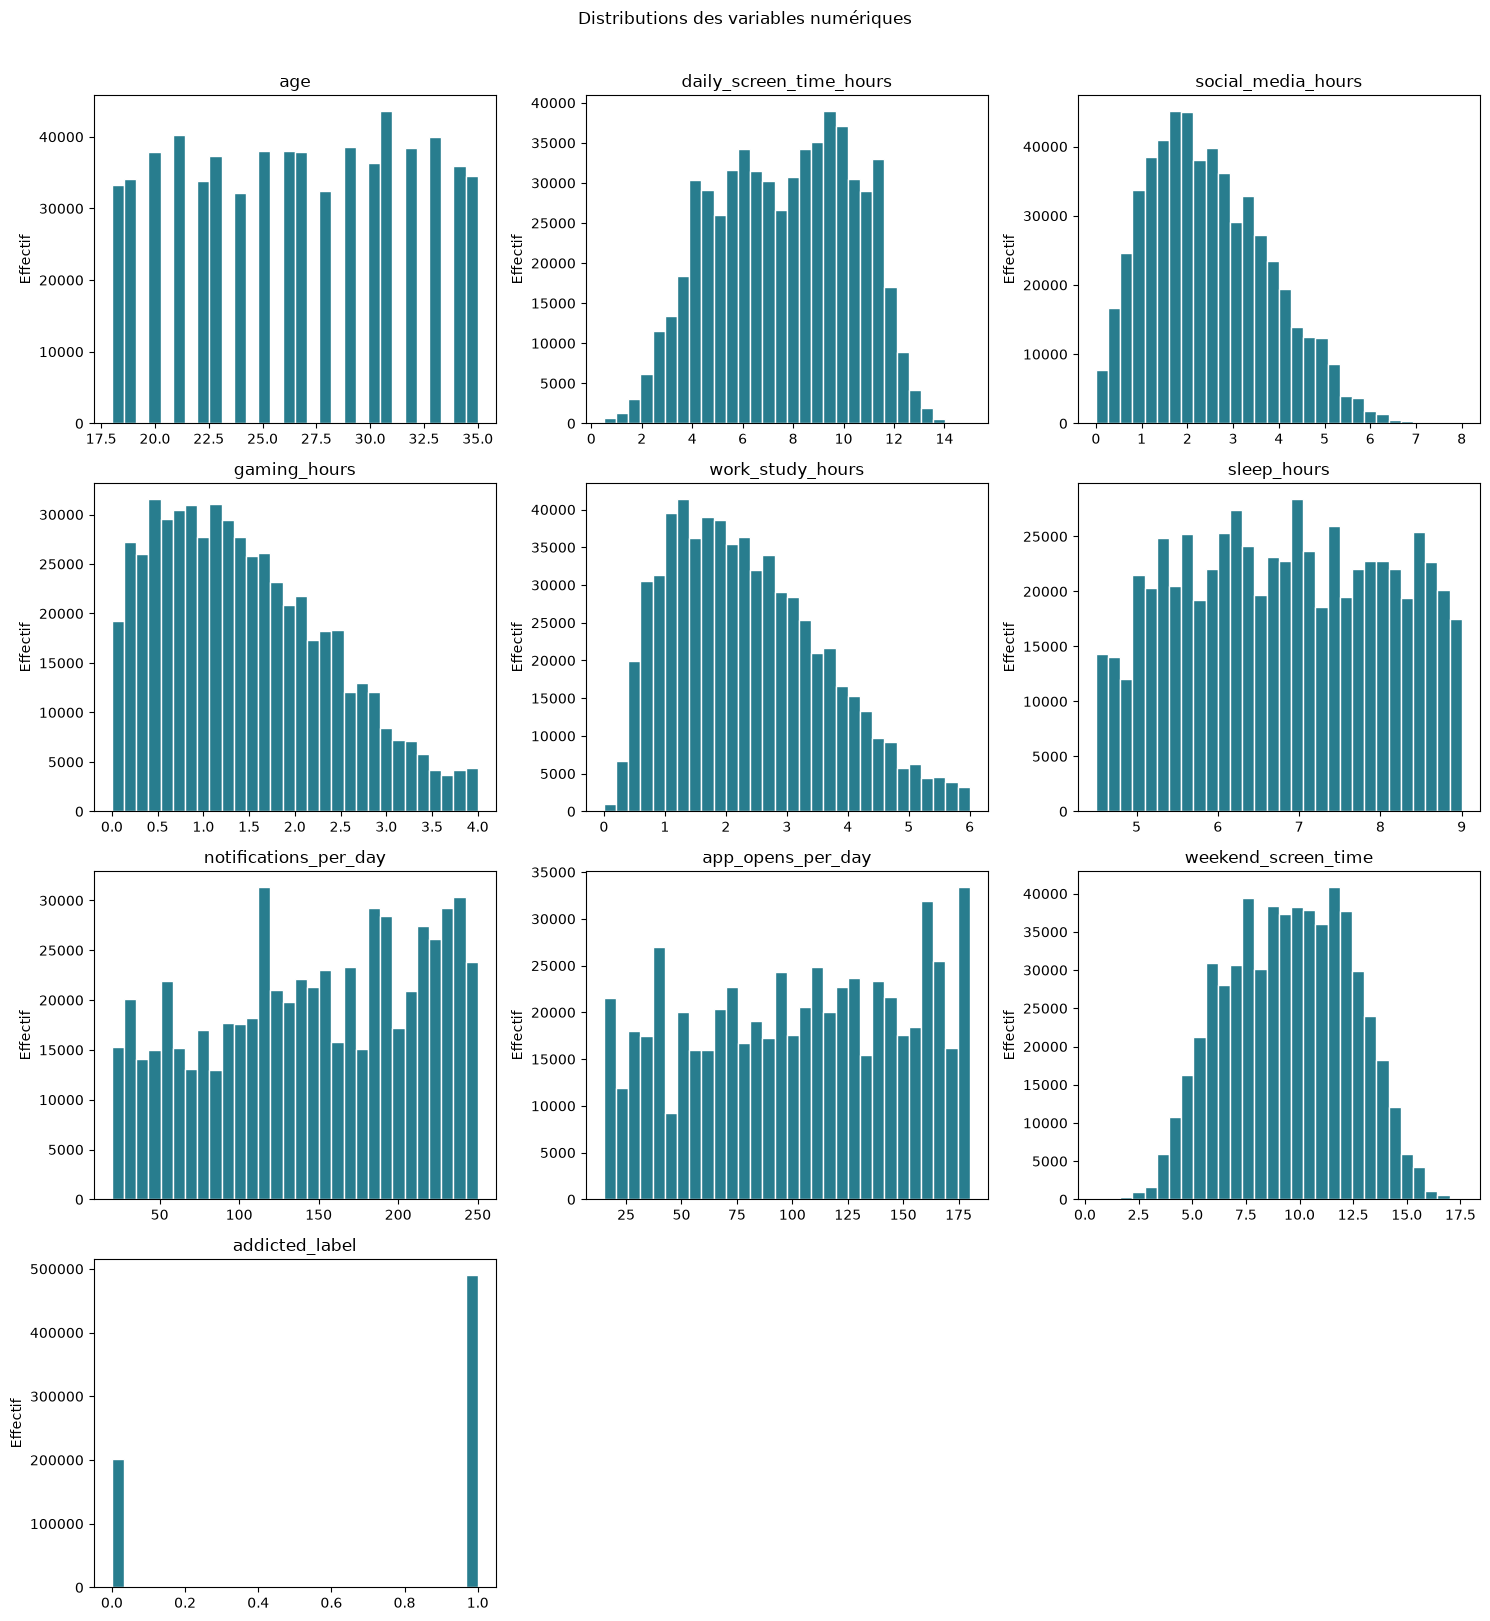

In [21]:
# Graphiques des distributions numériques
if numeric_cols:
    ncols = 3
    nrows = (len(numeric_cols) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
    axes = np.array(axes).reshape(-1)
    for ax, col in zip(axes, numeric_cols):
        values = train[col].dropna()
        ax.hist(values, bins=30, color="#287D8E", edgecolor="white")
        ax.set_title(col)
        ax.set_ylabel("Effectif")
    for ax in axes[len(numeric_cols):]:
        ax.set_visible(False)
    fig.suptitle("Distributions des variables numériques", y=1.01)
    plt.tight_layout()
    plt.show()


### Interprétation
 ces histogrammes permettent de repérer asymétries, valeurs concentrées et éventuels groupes. Les mesures extrêmes sont à vérifier dans leur contexte, pas à supprimer automatiquement

In [24]:
# Valeurs atypiques selon la règle IQR (diagnostic descriptif)
if numeric_cols:
    outlier_rows = []
    for col in numeric_cols:
        values = train[col].dropna()
        if values.empty:
            continue
        q1, q3 = values.quantile([0.25, 0.75])
        iqr = q3 - q1
        count = ((values < q1 - 1.5 * iqr) | (values > q3 + 1.5 * iqr)).sum()
        outlier_rows.append({"variable": col, "valeurs_atypiques_IQR": int(count),
                             "pourcentage": round(count / len(values) * 100, 2)})
    outliers = pd.DataFrame(outlier_rows).set_index("variable")
    print("\nDiagnostic des valeurs atypiques (règle 1,5 x IQR) :")
    display(outliers.sort_values("pourcentage", ascending=False))
    


Diagnostic des valeurs atypiques (règle 1,5 x IQR) :


,valeurs_atypiques_IQR,pourcentage
variable,,
social_media_hours,1209,0.22
work_study_hours,300,0.05
daily_screen_time_hours,0,0.00
age,0,0.00
gaming_hours,0,0.00
sleep_hours,0,0.00
notifications_per_day,0,0.00
app_opens_per_day,0,0.00
weekend_screen_time,6,0.00


la règle IQR signale des observations à examiner, pas nécessairement des erreurs. Conserver ou transformer ces valeurs dépend du domaine et du modèle


Moyennes et médianes numériques par classe cible :


age        daily_screen_time_hours         \
                 mean median                    mean median   
addicted_label                                                
0               26.58   27.0                    5.04   5.04   
1               26.63   27.0                    8.71   9.07   

               social_media_hours        gaming_hours        work_study_hours  \
                             mean median         mean median             mean   
addicted_label                                                                  
0                            1.38   1.29         1.16   1.07             1.87   
1                            2.92   2.82         1.58   1.48             2.57   

                      sleep_hours        notifications_per_day         \
               median        mean median                  mean median   
addicted_label                                                          
0                1.75        6.72   6.72                147.09  154.0   
1                2.47        6.84   6.84                145.41  150.0   

               app_opens_per_day        weekend_screen_time         
                            mean median                mean median  
addicted_label                                                      
0                          97.87   99.0                6.85   6.82  
1                         104.59  109.0               10.56  10.79

Variables numériques avec les écarts de moyenne les plus marqués (classe 1 moins classe 0) :


,écart_de_moyenne
app_opens_per_day,6.72
weekend_screen_time,3.71
daily_screen_time_hours,3.66
notifications_per_day,-1.68
social_media_hours,1.54
work_study_hours,0.70
gaming_hours,0.42
sleep_hours,0.12


Interprétation : un écart décrit une association observée avec la cible; il ne démontre pas une relation causale.

Répartition de addicted_label (%) selon gender :


addicted_label,0,1
gender,,
Female,29.6,70.4
Male,27.7,72.3
Other,29.9,70.1
[Manquant],29.1,70.9



Répartition de addicted_label (%) selon stress_level :


addicted_label,0,1
stress_level,,
High,28.9,71.1
Low,28.9,71.1
Medium,29.4,70.6
[Manquant],29.1,70.9



Répartition de addicted_label (%) selon academic_work_impact :


addicted_label,0,1
academic_work_impact,,
No,28.9,71.1
Yes,29.2,70.8
[Manquant],29.1,70.9


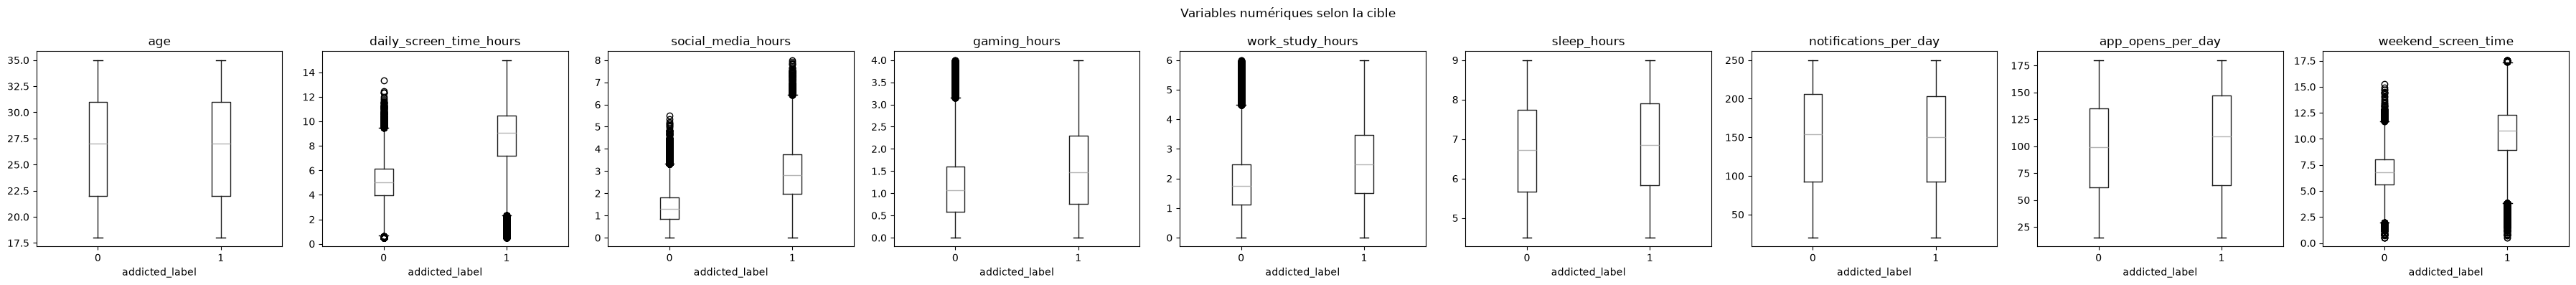

In [25]:
# Relations avec la cible
if TARGET in train.columns:
    if numeric_cols:
        target_numeric = [col for col in numeric_cols if col != TARGET]
        if target_numeric:
            grouped = train.groupby(TARGET, dropna=False)[target_numeric].agg(["mean", "median"])
            print("\nMoyennes et médianes numériques par classe cible :")
            display(grouped.round(2))
            if train[TARGET].nunique(dropna=True) == 2:
                rates = train.groupby(TARGET)[target_numeric].mean()
                if len(rates) == 2:
                    deltas = (rates.iloc[-1] - rates.iloc[0]).sort_values(
                        key=lambda values: values.abs(), ascending=False
                    )
                    print("Variables numériques avec les écarts de moyenne les plus marqués "
                          f"(classe {rates.index[-1]} moins classe {rates.index[0]}) :")
                    display(deltas.head(8).to_frame("écart_de_moyenne").round(2))
                    print("Interprétation : un écart décrit une association observée avec la cible; "
                          "il ne démontre pas une relation causale.")
    if categorical_cols:
        for col in categorical_cols:
            if col == TARGET:
                continue
            rates = pd.crosstab(train[col].fillna("[Manquant]"), train[TARGET], normalize="index") * 100
            print(f"\nRépartition de {TARGET} (%) selon {col} :")
            display(rates.round(1))
    if train[TARGET].nunique(dropna=True) == 2 and numeric_cols:
        target_numeric = [col for col in numeric_cols if col != TARGET]
        if target_numeric:
            fig, axes = plt.subplots(1, len(target_numeric), figsize=(4 * len(target_numeric), 4))
            axes = np.array(axes).reshape(-1)
            for ax, col in zip(axes, target_numeric):
                train.boxplot(column=col, by=TARGET, ax=ax, grid=False)
                ax.set_title(col)
                ax.set_xlabel(TARGET)
            fig.suptitle("Variables numériques selon la cible")
            plt.tight_layout()
            plt.show()


Matrice de corrélation de Pearson :


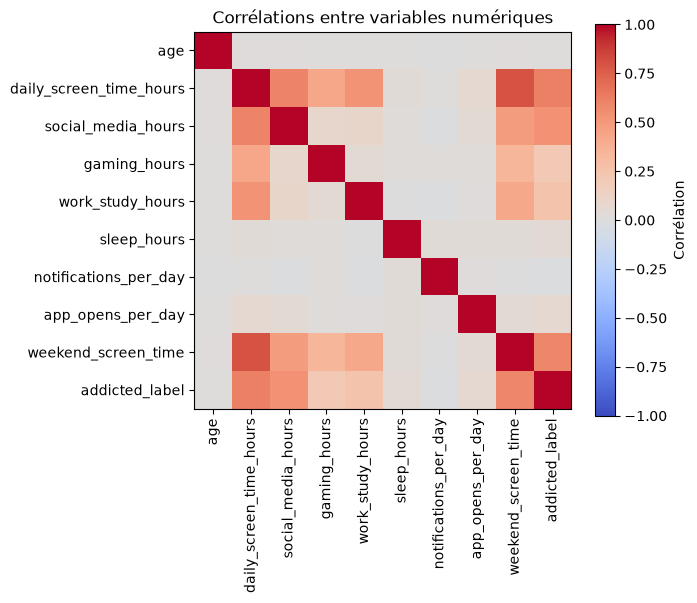

In [30]:
# Corrélations numériques
if len(numeric_cols) >= 2:
    corr = train[numeric_cols].corr(numeric_only=True)
    print("\nMatrice de corrélation de Pearson :")
    fig, ax = plt.subplots(figsize=(max(7, len(numeric_cols) * 0.7),
                                    max(5, len(numeric_cols) * 0.6)))
    image = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
    ax.set_xticks(range(len(corr.columns)), labels=corr.columns, rotation=90)
    ax.set_yticks(range(len(corr.index)), labels=corr.index)
    fig.colorbar(image, ax=ax, label="Corrélation")
    ax.set_title("Corrélations entre variables numériques")
    plt.tight_layout()
    plt.show()
    

Interprétation : Pearson mesure une association linéaire et peut être sensible aux valeurs extrêmes. Une forte corrélation entre variables explicatives peut signaler de la redondance; la corrélation avec la cible ne suffit pas à établir une causalité.

EDA terminée. À retenir : traiter les valeurs manquantes, vérifier les valeurs atypiques, examiner l'équilibre de la cible et éviter toute fuite de données lors de la validation.

### Conclusion 
Les résultats montrent 691 369 lignes, aucun doublon exact et jusqu’à 19,38 % de valeurs manquantes dans social_media_hours. La cible est répartie à 70,94 % pour la classe 1 et 29,06 % pour la classe 0. La classe 1 est associée à davantage de temps d’écran quotidien (8,71 h contre 5,04 h) et le week-end (10,56 h contre 6,85 h). Ces écarts sont descriptifs et ne prouvent pas une causalité.

## Feature Engineering

In [3]:
def add_behavior_features(df):
    """Ajoute des indicateurs comportementaux sans modifier le DataFrame source."""
    result = df.copy()
    screen_time = result["daily_screen_time_hours"].replace(0, np.nan)
    sleep_time = result["sleep_hours"].replace(0, np.nan)

    result["screen_time_ratio"] = result["daily_screen_time_hours"] / 24
    result["social_media_ratio"] = result["social_media_hours"] / screen_time
    result["gaming_ratio"] = result["gaming_hours"] / screen_time
    result["recreational_screen_time"] = (
        result["social_media_hours"] + result["gaming_hours"]
    )
    result["total_leisure_hours"] = (
        24 - result["sleep_hours"] - result["work_study_hours"]
    )
    result["weekend_screen_ratio"] = (
        result["weekend_screen_time"] / screen_time
    )
    result["screen_sleep_ratio"] = (
        result["daily_screen_time_hours"] / sleep_time
    )
    result["app_usage_intensity"] = (
        result["app_opens_per_day"] / screen_time
    )
    result["notification_intensity"] = (
        result["notifications_per_day"] / screen_time
    )
    return result


# Même transformation pour l'entraînement et la soumission; la cible n'est pas utilisée.
train = add_behavior_features(train)
test = pd.read_csv("data/test.csv", index_col="id")
test = add_behavior_features(test)

new_features = [
    "screen_time_ratio",
    "social_media_ratio",
    "gaming_ratio",
    "recreational_screen_time",
    "total_leisure_hours",
    "weekend_screen_ratio",
    "screen_sleep_ratio",
    "app_usage_intensity",
    "notification_intensity",
]
print("Variables comportementales créées :")
display(train[new_features].describe().T.round(3))

print("Interprétations :")
print("- screen_time_ratio représente la part des 24 heures consacrée à l'écran.")
print("- social_media_ratio et gaming_ratio rapportent chaque activité au temps d'écran total.")
print("- recreational_screen_time additionne réseaux sociaux et jeux; si l'une des mesures manque, le résultat reste manquant.")
print("- total_leisure_hours est un proxy du temps éveillé hors travail/études, pas une mesure directe des loisirs.")
print("- weekend_screen_ratio compare le temps d'écran du week-end au temps d'écran quotidien fourni.")
print("- screen_sleep_ratio compare écran et sommeil; les deux intensités comptent les ouvertures/notifications par heure d'écran.")
print("- Les divisions par zéro et les données manquantes produisent NaN. Les ratios ne sont pas tronqués : des valeurs > 1 peuvent signaler des mesures non parfaitement comparables.")
print(f"\nDimensions après transformation : train={train.shape}, test={test.shape}")

Variables comportementales créées :


,count,mean,std,min,25%,50%,75%,max
screen_time_ratio,595515.0,0.318,0.113,0.021,0.228,0.324,0.410,0.625
social_media_ratio,502260.0,0.327,0.134,0.000,0.231,0.330,0.418,0.885
gaming_ratio,507723.0,0.197,0.111,0.000,0.107,0.199,0.274,0.800
recreational_screen_time,484281.0,3.930,1.679,0.010,2.640,3.820,5.110,11.290
total_leisure_hours,599689.0,14.829,1.762,9.080,13.630,14.880,16.110,19.390
weekend_screen_ratio,517906.0,1.330,0.498,0.085,1.075,1.241,1.452,20.440
screen_sleep_ratio,559350.0,1.159,0.469,0.056,0.800,1.139,1.463,3.289
app_usage_intensity,529819.0,15.993,12.838,1.093,8.257,13.605,19.653,360.000
notification_intensity,540721.0,22.993,18.707,1.375,11.757,19.281,28.689,500.000


Interprétations :
- screen_time_ratio représente la part des 24 heures consacrée à l'écran.
- social_media_ratio et gaming_ratio rapportent chaque activité au temps d'écran total.
- recreational_screen_time additionne réseaux sociaux et jeux; si l'une des mesures manque, le résultat reste manquant.
- total_leisure_hours est un proxy du temps éveillé hors travail/études, pas une mesure directe des loisirs.
- weekend_screen_ratio compare le temps d'écran du week-end au temps d'écran quotidien fourni.
- screen_sleep_ratio compare écran et sommeil; les deux intensités comptent les ouvertures/notifications par heure d'écran.
- Les divisions par zéro et les données manquantes produisent NaN. Les ratios ne sont pas tronqués : des valeurs > 1 peuvent signaler des mesures non parfaitement comparables.

Dimensions après transformation : train=(691369, 22), test=(296302, 21)


## Preprossessing

In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from scipy import sparse

TARGET = "addicted_label"
X = train.drop(columns=[TARGET])
y = train[TARGET]

# Split stratifié pour conserver la proportion des classes.
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

numeric_features = X_train.select_dtypes(include="number").columns.tolist()
categorical_features = X_train.select_dtypes(exclude="number").columns.tolist()

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=True)),
])

preprocessor = ColumnTransformer(transformers=[
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features),
])

# L'ajustement des imputers, du scaler et de l'encodeur se fait sur X_train uniquement.
X_train_processed = preprocessor.fit_transform(X_train)
X_valid_processed = preprocessor.transform(X_valid)


def all_finite(matrix):
    values = matrix.data if sparse.issparse(matrix) else matrix
    return np.isfinite(values).all()


assert TARGET not in X_train.columns
assert X_train_processed.shape[0] == len(y_train)
assert X_valid_processed.shape[0] == len(y_valid)
assert all_finite(X_train_processed), "Valeurs non finies après preprocessing du train."
assert all_finite(X_valid_processed), "Valeurs non finies après preprocessing de la validation."

print(f"Variables numériques : {len(numeric_features)}")
print(f"Variables catégorielles : {len(categorical_features)}")
print(f"Train transformé : {X_train_processed.shape}")
print(f"Validation transformée : {X_valid_processed.shape}")
print(f"Proportion de classe 1 - train : {y_train.mean():.3f}")
print(f"Proportion de classe 1 - validation : {y_valid.mean():.3f}")
print("Aucune valeur manquante ou infinie après transformation.")
print("Le preprocessing a été ajusté uniquement sur le train, sans fuite de validation.")

Variables numériques : 18
Variables catégorielles : 3
Train transformé : (553095, 44)
Validation transformée : (138274, 44)
Proportion de classe 1 - train : 0.709
Proportion de classe 1 - validation : 0.709
Aucune valeur manquante ou infinie après transformation.
Le preprocessing a été ajusté uniquement sur le train, sans fuite de validation.


## Benchmark des modèles

In [5]:
from time import perf_counter

from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from xgboost import XGBClassifier

# CatBoost reçoit les colonnes catégorielles brutes; les autres modèles
# utilisent les matrices prétraitées communes calculées plus haut.
X_train_cat = X_train.copy()
X_valid_cat = X_valid.copy()
for column in categorical_features:
    X_train_cat[column] = X_train_cat[column].fillna("__MANQUANT__").astype(str)
    X_valid_cat[column] = X_valid_cat[column].fillna("__MANQUANT__").astype(str)

models = [
    ("Logistic Regression", LogisticRegression(max_iter=1000, solver="lbfgs")),
    ("Random Forest", RandomForestClassifier(
        n_estimators=120,
        max_depth=16,
        min_samples_leaf=5,
        max_features="sqrt",
        n_jobs=-1,
        random_state=42,
    )),
    ("XGBoost", XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        tree_method="hist",
        eval_metric="logloss",
        n_jobs=-1,
        random_state=42,
        verbosity=0,
    )),
    ("LightGBM", LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        max_bin=127,
        n_jobs=-1,
        random_state=42,
        verbosity=-1,
    )),
    ("CatBoost", CatBoostClassifier(
        iterations=300,
        depth=7,
        learning_rate=0.05,
        loss_function="Logloss",
        eval_metric="AUC",
        random_seed=42,
        thread_count=-1,
        verbose=False,
        allow_writing_files=False,
    )),
]

results = []
for model_name, model in models:
    if model_name == "CatBoost":
        model_train = X_train_cat
        model_valid = X_valid_cat
        fit_options = {"cat_features": categorical_features}
    else:
        model_train = X_train_processed
        model_valid = X_valid_processed
        fit_options = {}

    start_time = perf_counter()
    model.fit(model_train, y_train, **fit_options)
    training_seconds = perf_counter() - start_time

    probabilities = model.predict_proba(model_valid)[:, 1]
    predictions = (probabilities >= 0.5).astype(int)
    results.append({
        "Modèle": model_name,
        "ROC-AUC": roc_auc_score(y_valid, probabilities),
        "PR-AUC (AP)": average_precision_score(y_valid, probabilities),
        "Accuracy": accuracy_score(y_valid, predictions),
        "Precision": precision_score(y_valid, predictions, zero_division=0),
        "Recall": recall_score(y_valid, predictions, zero_division=0),
        "F1": f1_score(y_valid, predictions, zero_division=0),
        "Temps entraînement (s)": training_seconds,
    })
    print(f"{model_name} terminé en {training_seconds:.1f} s")

benchmark_results = (
    pd.DataFrame(results)
    .set_index("Modèle")
    .sort_values("ROC-AUC", ascending=False)
)
print("\nBenchmark (trié par ROC-AUC, métrique principale) :")
display(benchmark_results.round(4))
print("PR-AUC est calculée avec Average Precision. Precision, Recall et F1 utilisent "
      "un seuil de décision de 0,5; les modèles ne sont pas encore optimisés ni ajustés.")

Logistic Regression terminé en 15.0 s
Random Forest terminé en 626.5 s
XGBoost terminé en 53.5 s
LightGBM terminé en 33.1 s
CatBoost terminé en 346.1 s

Benchmark (trié par ROC-AUC, métrique principale) :


,ROC-AUC,PR-AUC (AP),Accuracy,Precision,Recall,F1,Temps entraînement (s)
Modèle,,,,,,,
XGBoost,0.9541,0.9814,0.8882,0.9146,0.9292,0.9219,53.5037
LightGBM,0.9537,0.9812,0.8874,0.9144,0.9281,0.9212,33.0971
CatBoost,0.9477,0.9787,0.8789,0.9075,0.9235,0.9154,346.0586
Random Forest,0.9390,0.9752,0.8666,0.8937,0.9215,0.9074,626.4530
Logistic Regression,0.9176,0.9664,0.8448,0.8756,0.9107,0.8928,14.9971


PR-AUC est calculée avec Average Precision. Precision, Recall et F1 utilisent un seuil de décision de 0,5; les modèles ne sont pas encore optimisés ni ajustés.


### Validation croisée et optimisation du seuil

In [6]:
from sklearn.base import clone
from sklearn.metrics import precision_recall_curve
from sklearn.model_selection import StratifiedKFold

cv_models = {
    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        tree_method="hist",
        eval_metric="logloss",
        n_jobs=-1,
        random_state=42,
        verbosity=0,
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        max_bin=127,
        n_jobs=-1,
        random_state=42,
        verbosity=-1,
    ),
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
cv_rows = []
oof_predictions = {}

for model_name, model_template in cv_models.items():
    oof_probabilities = np.full(len(y_train), np.nan)
    fold_roc_auc = []
    fold_pr_auc = []

    for fold_number, (fit_indices, fold_indices) in enumerate(
        cv.split(X_train, y_train), start=1
    ):
        fold_preprocessor = clone(preprocessor)
        fold_X_train = fold_preprocessor.fit_transform(X_train.iloc[fit_indices])
        fold_X_valid = fold_preprocessor.transform(X_train.iloc[fold_indices])

        fold_model = clone(model_template)
        fold_model.fit(fold_X_train, y_train.iloc[fit_indices])
        fold_probabilities = fold_model.predict_proba(fold_X_valid)[:, 1]
        oof_probabilities[fold_indices] = fold_probabilities

        fold_roc_auc.append(roc_auc_score(y_train.iloc[fold_indices], fold_probabilities))
        fold_pr_auc.append(
            average_precision_score(y_train.iloc[fold_indices], fold_probabilities)
        )
        print(f"{model_name} - fold {fold_number}/3 terminé")

    oof_predictions[model_name] = oof_probabilities
    cv_rows.append({
        "Modèle": model_name,
        "ROC-AUC moyen": np.mean(fold_roc_auc),
        "ROC-AUC écart-type": np.std(fold_roc_auc, ddof=1),
        "PR-AUC moyen": np.mean(fold_pr_auc),
        "PR-AUC écart-type": np.std(fold_pr_auc, ddof=1),
    })

cv_results = (
    pd.DataFrame(cv_rows)
    .set_index("Modèle")
    .sort_values("ROC-AUC moyen", ascending=False)
)
print("\nValidation croisée stratifiée (3 folds) :")
display(cv_results.round(4))

best_model_name = cv_results.index[0]
best_oof_probabilities = oof_predictions[best_model_name]
assert np.isfinite(best_oof_probabilities).all()

# Le seuil est choisi uniquement sur les prédictions out-of-fold du train.
precision_values, recall_values, thresholds = precision_recall_curve(
    y_train, best_oof_probabilities
)
f1_values = (
    2 * precision_values[:-1] * recall_values[:-1]
    / (precision_values[:-1] + recall_values[:-1] + 1e-12)
)
best_threshold = thresholds[np.argmax(f1_values)]
oof_best_f1 = np.max(f1_values)

# Réentraînement sur tout le train de développement, puis évaluation sur le holdout intact.
selected_model = clone(cv_models[best_model_name])
selected_model.fit(X_train_processed, y_train)
valid_probabilities = selected_model.predict_proba(X_valid_processed)[:, 1]

threshold_rows = []
for threshold_name, threshold in [
    ("Seuil par défaut (0,5)", 0.5),
    ("Seuil choisi sur OOF", best_threshold),
]:
    valid_predictions = (valid_probabilities >= threshold).astype(int)
    threshold_rows.append({
        "Seuil": threshold_name,
        "Valeur": threshold,
        "ROC-AUC": roc_auc_score(y_valid, valid_probabilities),
        "PR-AUC (AP)": average_precision_score(y_valid, valid_probabilities),
        "Accuracy": accuracy_score(y_valid, valid_predictions),
        "Precision": precision_score(y_valid, valid_predictions, zero_division=0),
        "Recall": recall_score(y_valid, valid_predictions, zero_division=0),
        "F1": f1_score(y_valid, valid_predictions, zero_division=0),
    })

print(f"Modèle retenu par ROC-AUC CV : {best_model_name}")
print(f"Seuil sélectionné sur OOF : {best_threshold:.4f} (F1 OOF = {oof_best_f1:.4f})")
print("\nÉvaluation sur le holdout non utilisé pour choisir le seuil :")
display(pd.DataFrame(threshold_rows).set_index("Seuil").round(4))
print("ROC-AUC et PR-AUC ne dépendent pas du seuil; le seuil optimisé vise le F1 "
      "sur les prédictions OOF et peut être adapté selon le coût des faux positifs/négatifs.")

XGBoost - fold 1/3 terminé
XGBoost - fold 2/3 terminé
XGBoost - fold 3/3 terminé
LightGBM - fold 1/3 terminé
LightGBM - fold 2/3 terminé
LightGBM - fold 3/3 terminé

Validation croisée stratifiée (3 folds) :


,ROC-AUC moyen,ROC-AUC écart-type,PR-AUC moyen,PR-AUC écart-type
Modèle,,,,
XGBoost,0.9545,0.0007,0.9816,0.0003
LightGBM,0.9545,0.0008,0.9816,0.0003


Modèle retenu par ROC-AUC CV : XGBoost
Seuil sélectionné sur OOF : 0.4807 (F1 OOF = 0.9222)

Évaluation sur le holdout non utilisé pour choisir le seuil :


,Valeur,ROC-AUC,PR-AUC (AP),Accuracy,Precision,Recall,F1
Seuil,,,,,,,
"Seuil par défaut (0,5)",0.5000,0.9541,0.9814,0.8882,0.9146,0.9292,0.9219
Seuil choisi sur OOF,0.4807,0.9541,0.9814,0.8873,0.9091,0.9347,0.9217


ROC-AUC et PR-AUC ne dépendent pas du seuil; le seuil optimisé vise le F1 sur les prédictions OOF et peut être adapté selon le coût des faux positifs/négatifs.


### LightGBM est notre meilleur choix pragmatique pour la suite.
score équivalent à XGBoost ;
entraînement plus rapide ;
excellent comportement sur ce volume de données ;
possibilité d'effectuer davantage d'expérimentations rapidement.

## Modeles

### Explainable AI avec SHAP

Importance globale : moyenne de la valeur absolue SHAP


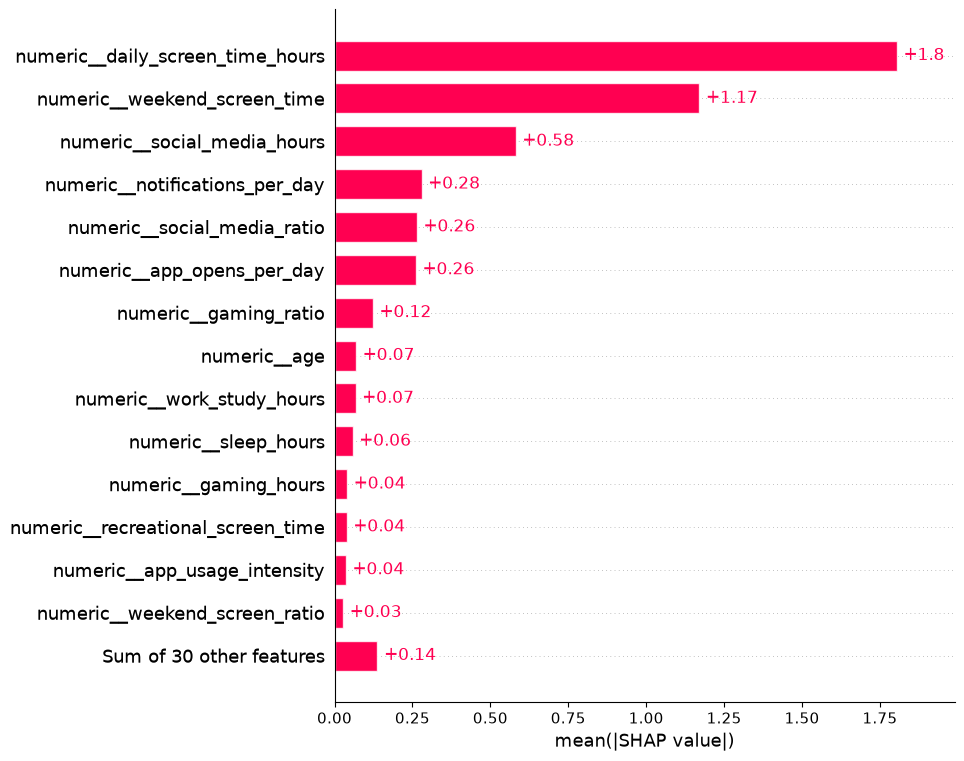

Distribution des contributions par variable


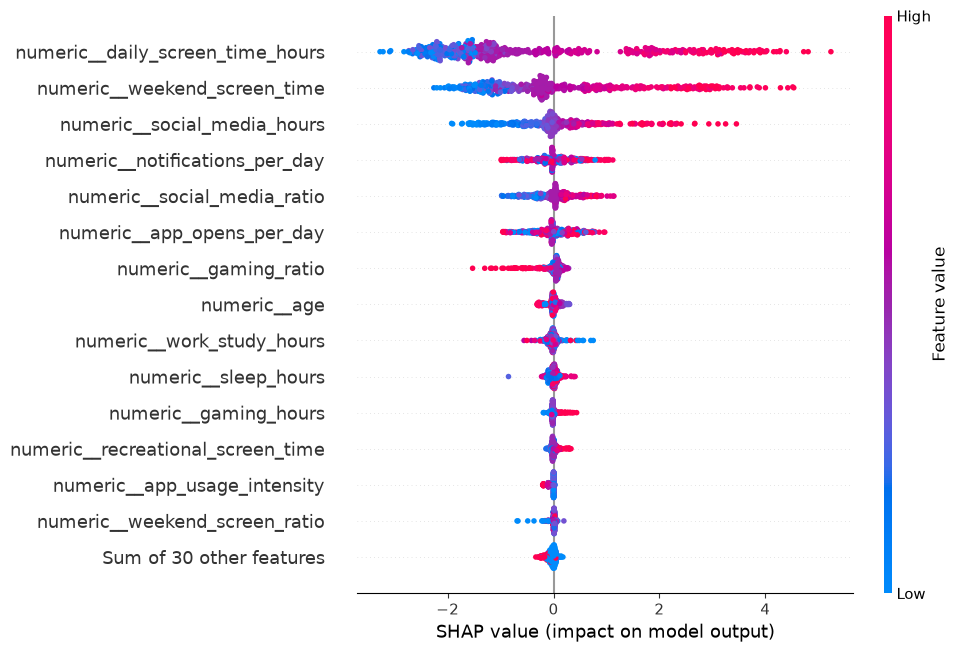

Cas expliqué : probabilité prédite = 1.000; classe réelle = 1.
Les SHAP positifs augmentent le score brut en faveur de la classe 1; les SHAP négatifs le diminuent.


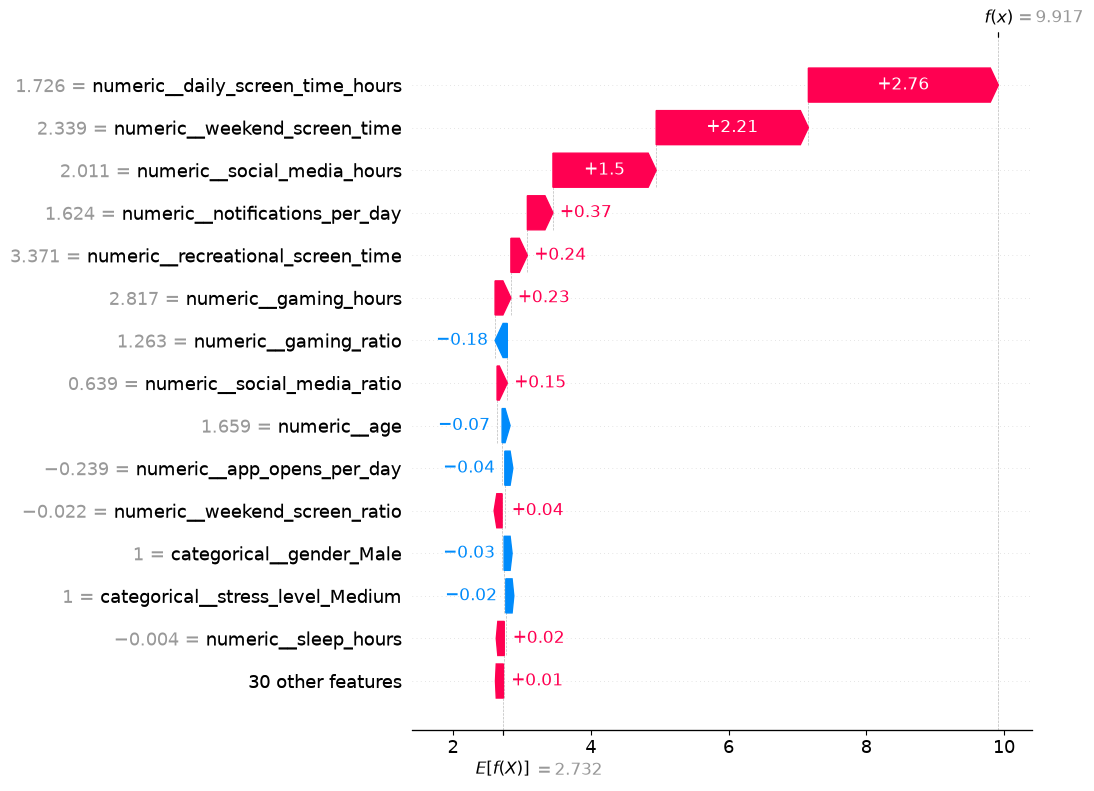

Facteurs qui diminuent le plus le score de ce cas :


,valeur_SHAP
numeric__gaming_ratio,-0.1773
numeric__age,-0.0728
numeric__app_opens_per_day,-0.0395
categorical__gender_Male,-0.0290
categorical__stress_level_Medium,-0.0250


Facteurs qui augmentent le plus le score de ce cas :


,valeur_SHAP
numeric__daily_screen_time_hours,2.7582
numeric__weekend_screen_time,2.2095
numeric__social_media_hours,1.4990
numeric__notifications_per_day,0.3715
numeric__recreational_screen_time,0.2392


Interprétation : l'importance globale décrit le comportement moyen du modèle sur l'échantillon; l'explication locale décrit cette prédiction précise. Les valeurs SHAP expliquent le modèle, pas une causalité réelle.


In [5]:
import shap
from lightgbm import LGBMClassifier

# Le benchmark retient LightGBM pour son score équivalent et son temps d'entraînement inférieur.
shap_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    max_bin=127,
    n_jobs=-1,
    random_state=42,
    verbosity=-1,
)
shap_model.fit(X_train_processed, y_train)

# Échantillon déterministe du holdout pour garder le calcul SHAP rapide.
sample_size = min(500, len(X_valid_processed))
rng = np.random.default_rng(42)
sample_indices = np.sort(
    rng.choice(len(X_valid_processed), size=sample_size, replace=False)
)
X_shap = X_valid_processed[sample_indices]
feature_names = preprocessor.get_feature_names_out()
X_shap_df = pd.DataFrame(X_shap, columns=feature_names)

explainer = shap.TreeExplainer(shap_model)
shap_values = explainer(X_shap_df)

print("Importance globale : moyenne de la valeur absolue SHAP")
shap.plots.bar(shap_values, max_display=15)
plt.show()

print("Distribution des contributions par variable")
shap.plots.beeswarm(shap_values, max_display=15)
plt.show()

# Cas du holdout où le modèle attribue la plus forte probabilité à la classe positive.
sample_probabilities = shap_model.predict_proba(X_shap_df)[:, 1]
local_index = int(np.argmax(sample_probabilities))
original_index = sample_indices[local_index]
local_probability = sample_probabilities[local_index]
local_actual = int(y_valid.iloc[original_index])

print(f"Cas expliqué : probabilité prédite = {local_probability:.3f}; "
      f"classe réelle = {local_actual}.")
print("Les SHAP positifs augmentent le score brut en faveur de la classe 1; "
      "les SHAP négatifs le diminuent.")
shap.plots.waterfall(shap_values[local_index], max_display=15)
plt.show()

local_contributions = pd.Series(
    shap_values[local_index].values,
    index=feature_names,
).sort_values()
print("Facteurs qui diminuent le plus le score de ce cas :")
display(local_contributions.head(5).to_frame("valeur_SHAP").round(4))
print("Facteurs qui augmentent le plus le score de ce cas :")
display(local_contributions.tail(5).sort_values(ascending=False)
        .to_frame("valeur_SHAP").round(4))

print("Interprétation : l'importance globale décrit le comportement moyen du modèle sur "
      "l'échantillon; l'explication locale décrit cette prédiction précise. Les valeurs SHAP "
      "expliquent le modèle, pas une causalité réelle.")

## Optimisation LightGBM et soumission

In [6]:
from time import perf_counter

from sklearn.base import clone
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import ParameterSampler, StratifiedKFold
from lightgbm import LGBMClassifier

# Recherche volontairement limitée : 6 configurations, 3 folds stratifiés.
parameter_space = {
    "learning_rate": [0.03, 0.05, 0.07, 0.1],
    "num_leaves": [15, 31, 47, 63],
    "max_depth": [-1, 6, 8, 10],
    "min_child_samples": [20, 50, 100, 150],
    "subsample": [0.75, 0.85, 1.0],
    "colsample_bytree": [0.7, 0.85, 1.0],
    "reg_alpha": [0.0, 0.1, 0.5, 1.0],
    "reg_lambda": [0.0, 1.0, 5.0, 10.0],
}
parameter_candidates = list(ParameterSampler(
    parameter_space,
    n_iter=6,
    random_state=42,
))

cv_tuning = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
tuning_rows = []
tuning_base_params = {
    "n_estimators": 300,
    "subsample_freq": 1,
    "n_jobs": -1,
    "random_state": 42,
    "verbosity": -1,
}

for candidate_number, candidate_params in enumerate(parameter_candidates, start=1):
    fold_scores = []
    candidate_start = perf_counter()

    for fold_number, (fit_indices, fold_indices) in enumerate(
        cv_tuning.split(X_train, y_train), start=1
    ):
        fold_preprocessor = clone(preprocessor)
        fold_X_train = fold_preprocessor.fit_transform(X_train.iloc[fit_indices])
        fold_X_valid = fold_preprocessor.transform(X_train.iloc[fold_indices])
        fold_y_train = y_train.iloc[fit_indices]
        fold_y_valid = y_train.iloc[fold_indices]

        fold_model = LGBMClassifier(**tuning_base_params, **candidate_params)
        fold_model.fit(fold_X_train, fold_y_train)
        train_probabilities = fold_model.predict_proba(fold_X_train)[:, 1]
        valid_probabilities = fold_model.predict_proba(fold_X_valid)[:, 1]
        valid_predictions = (valid_probabilities >= 0.5).astype(int)

        fold_scores.append({
            "train_roc_auc": roc_auc_score(fold_y_train, train_probabilities),
            "roc_auc": roc_auc_score(fold_y_valid, valid_probabilities),
            "pr_auc": average_precision_score(fold_y_valid, valid_probabilities),
            "accuracy": accuracy_score(fold_y_valid, valid_predictions),
            "precision": precision_score(fold_y_valid, valid_predictions, zero_division=0),
            "recall": recall_score(fold_y_valid, valid_predictions, zero_division=0),
            "f1": f1_score(fold_y_valid, valid_predictions, zero_division=0),
        })
        print(f"Configuration {candidate_number}/6 - fold {fold_number}/3 terminée")

    fold_results = pd.DataFrame(fold_scores)
    tuning_rows.append({
        "configuration": candidate_number,
        **candidate_params,
        "ROC-AUC moyen": fold_results["roc_auc"].mean(),
        "ROC-AUC écart-type": fold_results["roc_auc"].std(ddof=1),
        "PR-AUC moyen": fold_results["pr_auc"].mean(),
        "F1 moyen (seuil 0,5)": fold_results["f1"].mean(),
        "Accuracy moyenne": fold_results["accuracy"].mean(),
        "Precision moyenne": fold_results["precision"].mean(),
        "Recall moyen": fold_results["recall"].mean(),
        "ROC-AUC train moyen": fold_results["train_roc_auc"].mean(),
        "Gap ROC-AUC train-validation": (
            fold_results["train_roc_auc"].mean() - fold_results["roc_auc"].mean()
        ),
        "Temps (s)": perf_counter() - candidate_start,
    })

lightgbm_tuning_results = (
    pd.DataFrame(tuning_rows)
    .sort_values(
        ["ROC-AUC moyen", "ROC-AUC écart-type", "Temps (s)"],
        ascending=[False, True, True],
    )
    .reset_index(drop=True)
)
print("\nRésultats de recherche, triés selon le critère principal :")
display(lightgbm_tuning_results.round(4))

baseline_roc_auc = 0.9545
best_tuning_row = lightgbm_tuning_results.iloc[0]
best_params = {
    parameter: best_tuning_row[parameter]
    for parameter in parameter_space
}
best_params["max_depth"] = int(best_params["max_depth"])
best_params["num_leaves"] = int(best_params["num_leaves"])
best_params["min_child_samples"] = int(best_params["min_child_samples"])

print(f"ROC-AUC CV de référence : {baseline_roc_auc:.4f}")
print(f"Meilleur ROC-AUC CV après tuning : {best_tuning_row['ROC-AUC moyen']:.4f} "
      f"(+{best_tuning_row['ROC-AUC moyen'] - baseline_roc_auc:+.4f})")
print(f"Écart-type CV : {best_tuning_row['ROC-AUC écart-type']:.4f}")
print(f"Gap ROC-AUC train-validation : {best_tuning_row['Gap ROC-AUC train-validation']:.4f}")
print("Meilleurs paramètres :", best_params)

# Refit final sur toutes les lignes étiquetées; test reste hors entraînement.
X_full = train.drop(columns=[TARGET])
y_full = train[TARGET]
X_test_full = test.reindex(columns=X_full.columns)
assert X_test_full.columns.equals(X_full.columns)

final_preprocessor = clone(preprocessor)
X_full_processed = final_preprocessor.fit_transform(X_full)
X_test_processed = final_preprocessor.transform(X_test_full)

final_model = LGBMClassifier(**tuning_base_params, **best_params)
final_fit_start = perf_counter()
final_model.fit(X_full_processed, y_full)
final_fit_seconds = perf_counter() - final_fit_start

submission_template = pd.read_csv("data/sample_submission.csv")
test_probabilities = final_model.predict_proba(X_test_processed)[:, 1]
submission = pd.DataFrame({
    "id": test.index.to_numpy(),
    TARGET: test_probabilities,
}).set_index("id").reindex(submission_template["id"])
submission = submission.rename_axis("id").reset_index()

assert submission.columns.tolist() == submission_template.columns.tolist()
assert len(submission) == len(test)
assert np.isfinite(submission[TARGET]).all()
assert submission["id"].equals(submission_template["id"])
submission.to_csv("submission.csv", index=False)

print(f"\nModèle final entraîné sur {len(X_full):,} lignes en {final_fit_seconds:.1f} s.")
print(f"Fichier créé : submission.csv ({len(submission):,} lignes)")
display(submission.head())

Configuration 1/6 - fold 1/3 terminée
Configuration 1/6 - fold 2/3 terminée
Configuration 1/6 - fold 3/3 terminée
Configuration 2/6 - fold 1/3 terminée
Configuration 2/6 - fold 2/3 terminée
Configuration 2/6 - fold 3/3 terminée
Configuration 3/6 - fold 1/3 terminée
Configuration 3/6 - fold 2/3 terminée
Configuration 3/6 - fold 3/3 terminée
Configuration 4/6 - fold 1/3 terminée
Configuration 4/6 - fold 2/3 terminée
Configuration 4/6 - fold 3/3 terminée
Configuration 5/6 - fold 1/3 terminée
Configuration 5/6 - fold 2/3 terminée
Configuration 5/6 - fold 3/3 terminée
Configuration 6/6 - fold 1/3 terminée
Configuration 6/6 - fold 2/3 terminée
Configuration 6/6 - fold 3/3 terminée

Résultats de recherche, triés selon le critère principal :


,configuration,subsample,reg_lambda,reg_alpha,num_leaves,min_child_samples,max_depth,learning_rate,colsample_bytree,ROC-AUC moyen,ROC-AUC écart-type,PR-AUC moyen,"F1 moyen (seuil 0,5)",Accuracy moyenne,Precision moyenne,Recall moyen,ROC-AUC train moyen,Gap ROC-AUC train-validation,Temps (s)
0,3,0.85,1.0,0.0,63,100,8,0.10,0.70,0.9615,0.0005,0.9845,0.9292,0.8989,0.9232,0.9353,0.9697,0.0082,366.4344
1,4,0.85,0.0,0.5,47,20,-1,0.07,0.70,0.9609,0.0006,0.9842,0.9284,0.8978,0.9226,0.9343,0.9658,0.0049,134.3371
2,6,1.00,0.0,0.5,31,100,-1,0.10,0.85,0.9608,0.0006,0.9842,0.9284,0.8978,0.9222,0.9347,0.9650,0.0042,161.8511
3,1,0.75,1.0,0.0,31,100,-1,0.05,0.85,0.9582,0.0006,0.9831,0.9256,0.8937,0.9190,0.9323,0.9601,0.0020,208.7533
4,5,1.00,0.0,0.0,63,150,6,0.05,0.85,0.9541,0.0005,0.9814,0.9216,0.8877,0.9135,0.9298,0.9573,0.0032,138.0909
5,2,1.00,5.0,1.0,31,20,6,0.03,0.70,0.9472,0.0004,0.9786,0.9148,0.8778,0.9052,0.9246,0.9486,0.0014,189.0978


ROC-AUC CV de référence : 0.9545
Meilleur ROC-AUC CV après tuning : 0.9615 (++0.0070)
Écart-type CV : 0.0005
Gap ROC-AUC train-validation : 0.0082
Meilleurs paramètres : {'learning_rate': np.float64(0.1), 'num_leaves': 63, 'max_depth': 8, 'min_child_samples': 100, 'subsample': np.float64(0.85), 'colsample_bytree': np.float64(0.7), 'reg_alpha': np.float64(0.0), 'reg_lambda': np.float64(1.0)}

Modèle final entraîné sur 691,369 lignes en 37.4 s.
Fichier créé : submission.csv (296,302 lignes)


,id,addicted_label
0,691369,0.999186
1,691370,0.966474
2,691371,0.938339
3,691372,0.985974
4,691373,0.996174


## Résultat important

Le passage de 0,9545 → 0,9615 ROC-AUC est un gain de +0,0070, ce qui est suffisamment intéressant pour justifier le tuning.

Le résultat est également assez propre :

ROC-AUC CV : 0,9615
écart-type : 0,0005 → très stable entre les folds
gap train/validation : 0,0082 → pas de signe évident de surapprentissage sévère
691 369 lignes utilisées pour le modèle final
37,4 s pour l'entraînement final
296 302 prédictions générées
identifiants vérifiés avec le fichier de soumission

Les paramètres retenus sont donc :

{
    "learning_rate": 0.1,
    "num_leaves": 63,
    "max_depth": 8,
    "min_child_samples": 100,
    "subsample": 0.85,
    "colsample_bytree": 0.7,
    "reg_alpha": 0,
    "reg_lambda": 1
}

## Modèle final

On peut maintenant considérer LightGBM comme le modèle officiel de SmartAddict AI.

Et surtout, on ne doit plus continuer à optimiser indéfiniment le modèle. Avec 0,9615 en CV, une faible variance et un fichier de soumission correctement généré, le prochain travail apporte davantage de valeur au projet.